In [ ]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

In [ ]:
a = '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse'
c = 'power_and_density/SNB/case_01'
to_load = [f'{a}/50%_fluence/{c}', f'{a}/100%_fluence/{c}' ,f'{a}/150%_fluence/{c}',f'{a}/200%_fluence/{c}', f'{a}/250%_fluence/{c}',f'{a}/300%_fluence/{c}']


cs = dict()

for i in to_load:
    i = Path(i)
    name = f"{i}"
    print(f"Loading {name}")
    cs[name] = Load.case_1D(i, guard_replace = False, use_squash=True)


Loading /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/50%_fluence/power_and_density/FL/case_01
- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:23:18, dmp file date 11/26/2024, 05:37:12
Skipping unnormalisation
Loading /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/100%_fluence/power_and_density/FL/case_01
- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:38:22, dmp file date 11/26/2024, 05:37:45
Skipping unnormalisation
Loading /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/150%_fluence/power_and_density/FL/case_01
- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:44:22, dmp file date 11/26/2024, 05:41:27
Skipping unnormalisation
Loading /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/powe

# Front tracking

In [ ]:


# detachment_loc_fcx_off = []
# for i, value in enumerate(case_2d_fcx_off['t']):
#     case = case_2d_fcx_off.isel(t=i)
#     profile_fcx_off = get_1d_poloidal_data(case, params = params, region = ('outer_lower'), sepadd = 6)
#     profile_fcx_off_plus1 = get_1d_poloidal_data(case, params = params, region = ('outer_lower'), sepadd = 7)
#     print(profile_fcx_off['front_poldist_5eV'][0])
#     detachment_loc_fcx_off.append(profile_fcx_off['front_poldist_5eV'][0])

# detachment_loc_fcx_on = []
# for i, value in enumerate(case_2d_fcx_on['t']):
#     case = case_2d_fcx_on.isel(t=i)
#     profile_fcx_on = get_1d_poloidal_data(case, params = params, region = ('outer_lower'), sepadd = 6)
#     profile_fcx_on_plus1 = get_1d_poloidal_data(case, params = params, region = ('outer_lower'), sepadd = 7)
#     print(profile_fcx_on['front_poldist_5eV'][0])
#     detachment_loc_fcx_on.append(profile_fcx_on['front_poldist_5eV'][0])



In [ ]:
def front_tracking(ds, more_fronts = False):
    ds = ds.copy()
    df = pd.DataFrame()
    df.index = range(ds.dims["t"])
    dist = ds["pos"].values
    df["t"] = ds["t"]

    def find_crossing(dist, data, threshold):

        # Find indices where the temperature crosses the threshold
        final_crossing = np.where(np.diff(np.signbit(data - threshold)))[0][-1]

        # Initialize a list to store crossing times
        crossing_times = []

        # Interpolate within each crossing interval to find the exact crossing time
        t1, t2 = dist[final_crossing], dist[final_crossing + 1]
        data1, data2 = data[final_crossing], data[final_crossing + 1]

        # Linear interpolation to find the crossing time
        location = t1 + (threshold - data1) * (t2 - t1) / (data2 - data1)

        return location



    for t in range(ds.dims["t"]):

        timeslice = ds.isel(t=t)
        df.loc[t, "5eV"] = find_crossing(dist, timeslice["Te"].values, 5)

        if more_fronts is True:
            df.loc[t, "Ne_peak"] = find_crossing(dist, timeslice["Ne"].values, timeslice["Ne"].values.max())
            df.loc[t, "Rneon"] = find_crossing(dist, timeslice["Rneon"].values, timeslice["Rneon"].values.max())
            df.loc[t, "iz_peak"] = find_crossing(dist, timeslice["Sd+_iz"].values, timeslice["Sd+_iz"].values.max())
            df.loc[t, "rec_peak"] = find_crossing(dist, timeslice["Sd+_rec"].values, timeslice["Sd+_rec"].values.max())

    # print(df.index)
    # print(df.index.duplicated())

    ds["front_pardist_5eV"] = xr.DataArray(df["5eV"].values, dims=["t"], coords={"t": ds["t"].values})
    ds["front_pardist_5eV"].attrs.update(dict(
        short_name = "5eV front pol. distance from target [m]",
        units = "m",
        origin = "sdtools")
    )

    
    if more_fronts is True:
        ds["front_poldist_Rpeak"] = xr.DataArray(df["Rneon"].values, dims = ["t"])
        ds["front_poldist_Rpeak"].attrs.update(dict(
            short_name = "R peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )

        ds["front_poldist_IZpeak"] = xr.DataArray(df["iz_peak"].values, dims = ["t"])
        ds["front_poldist_IZpeak"].attrs.update(dict(
            short_name = "IZ peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )

        ds["front_poldist_Nepeak"] = xr.DataArray(df["Ne_peak"].values, dims = ["t"])
        ds["front_poldist_Nepeak"].attrs.update(dict(
            short_name = "Ne peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )


    return ds
# ds["front_poldist_5eV"] = xr.DataArray(df["5eV"].values, dims = ["t"])

In [ ]:
powers = ['50%_fluence', '100%_fluence','150%_fluence', '200%_fluence', '250%_fluence', '300%_fluence']

print(cs.keys())

for i in powers:
    print(f"Calculating front tracking for {i}")
    ds = cs[f'{a}/{i}/{c}'].ds
    ds = front_tracking(ds, more_fronts = True)
    cs[f'{a}/{i}/{c}'] = ds
    print(cs[f'{a}/{i}/{c}'])

cs2 = cs.copy()


dict_keys(['/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/50%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/100%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/150%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/200%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/250%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01'])
Calculating front tracking for 50%_fluence
<xarray.Dataset>
Dimensions:      

In [ ]:
cs2 = cs.copy()
print(cs.keys())

dict_keys(['/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/50%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/100%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/150%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/200%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/250%_fluence/power_and_density/FL/case_01', '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01'])


/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/50%_fluence/power_and_density/FL/case_01
/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/100%_fluence/power_and_density/FL/case_01
/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/150%_fluence/power_and_density/FL/case_01
/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/200%_fluence/power_and_density/FL/case_01
/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/250%_fluence/power_and_density/FL/case_01
/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01


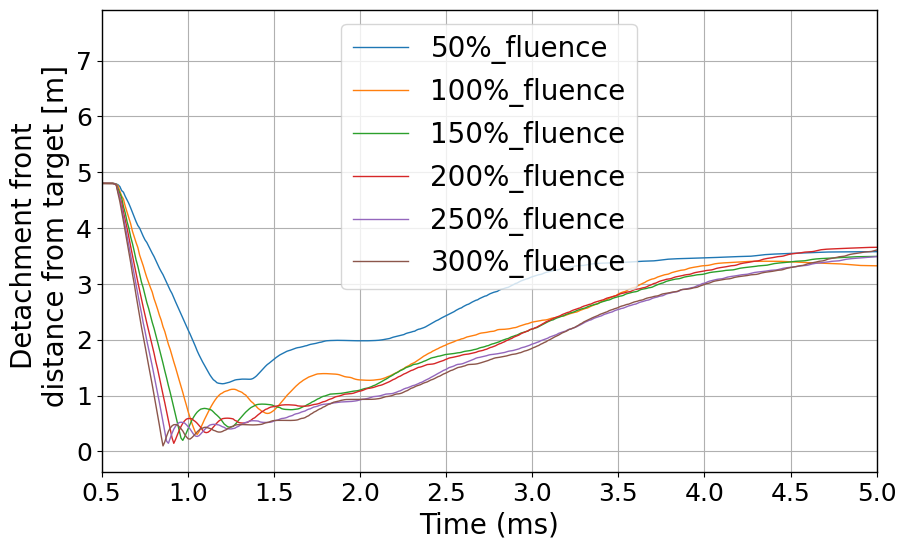

In [ ]:

fig,ax = plt.subplots(1,1,figsize=(10,6))
for value, i in enumerate(cs.keys()):
    print(i)
    label = powers[value]
    ds3 = cs2[f'{i}']
    ax.plot((ds3['t'].values*1e3)[:-1] - (ds3['t'].values*1e3)[0], 82 - ds3['front_pardist_5eV'].values[:-1], label = label, linewidth = 1)

ax.set_xlabel("Time (ms)", fontsize = 20)
ax.set_ylabel("Detachment front \n distance from target [m]", fontsize = 20)
ax.set_xbound(0.5, 5)
# ax.set_xscale('log')
ax.legend(fontsize = 20)

# Animation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import imageio.v2 as imageio
from tqdm.notebook import tqdm

def te_ti_ne_nd_with_detachment_animation(ds, front_positions, output_gif="te_ti_ne_nd_detachment.gif", output_mp4="te_ti_ne_nd_detachment.mp4", plot_source=False):
    times = ds['t'].values * 1e3
    times -= times[0]
    y = ds['y'].values[1:-1]

    def replace_guards(data):
        return data[1:-1]

    max_Te = max_Ti = max_ne = max_nd = -np.inf
    for t_index in range(len(times)):
        data = ds.isel(t=t_index)
        Te = replace_guards(np.squeeze(data['Te'].values))
        Ti = replace_guards(np.squeeze(data['Td+'].values))
        ne = replace_guards(np.squeeze(data['Ne'].values))
        nd = replace_guards(np.squeeze(data['Nd'].values))
        max_Te = max(max_Te, np.nanmax(Te))
        max_Ti = max(max_Ti, np.nanmax(Ti))
        max_ne = max(max_ne, np.nanmax(ne))
        max_nd = max(max_nd, np.nanmax(nd))

    initial_data = ds.isel(t=0)
    initial_Te = replace_guards(np.squeeze(initial_data['Te'].values))
    initial_Ti = replace_guards(np.squeeze(initial_data['Td+'].values))
    initial_ne = replace_guards(np.squeeze(initial_data['Ne'].values))
    initial_nd = replace_guards(np.squeeze(initial_data['Nd'].values))

    fig, axes = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [3, 1]})
    ax, ax_detachment = axes
    ax2 = ax.twinx()
    ax_source = ax_detachment.twinx() if plot_source else None

    # Swapped lines: Te and Ti on ax2, ne and nd on ax
    line_Te, = ax2.plot([], [], 'b-', label='Te')
    line_Ti, = ax2.plot([], [], 'r-', label='Ti')
    line_ne, = ax.plot([], [], 'b--', label='ne')
    line_nd, = ax.plot([], [], 'k--', label='nd')

    # Initial profile overlays
    ax.plot(y[::-1], initial_ne, color='blue', alpha=0.5, linestyle='--')
    ax.plot(y[::-1], initial_nd, color='black', alpha=0.5, linestyle='--')
    ax2.plot(y[::-1], initial_Te, color='blue', alpha=0.5)
    ax2.plot(y[::-1], initial_Ti, color='red', alpha=0.5)

    detachment_line, = ax_detachment.plot([], [], 'b-', label="Detachment Front Position")
    time_line = ax_detachment.axvline(0, color='red', linestyle='--', label="Current Time")

    # Set axis limits and labels
    ax.set_ylim(1e14, max(max_ne, max_nd))
    ax.set_yscale('log')
    ax.set_xlabel(r'$S_{\parallel}$ (m)')
    ax.set_ylabel('ne, nd (m⁻³)')

    ax2.set_ylim(0, max(max_Te, max_Ti) * 1.05)
    ax2.set_ylabel('Te, Ti (eV)')
    ax.grid(True, linestyle=':')

    ax_detachment.set_xlim(times[0], times[-1])
    ax_detachment.set_ylim(min(front_positions), max(front_positions))
    ax_detachment.set_xlabel("Time (ms)")
    ax_detachment.set_ylabel("Detachment Front Position (m)")

    if plot_source and ax_source:
        line_source, = ax_source.plot([], [], 'k--', label="Pressure Source")
        ax_source.set_ylabel("Pressure source (W/m³)")

    def init():
        line_Te.set_data([], [])
        line_Ti.set_data([], [])
        line_ne.set_data([], [])
        line_nd.set_data([], [])
        detachment_line.set_data([], [])
        time_line.set_xdata([])
        if plot_source and ax_source:
            line_source.set_data([], [])
        return [line_Te, line_Ti, line_ne, line_nd, detachment_line, time_line]

    def update(frame):
        t_index = frame
        data = ds.isel(t=t_index)
        Te = replace_guards(np.squeeze(data['Te'].values))
        Ti = replace_guards(np.squeeze(data['Td+'].values))
        ne = replace_guards(np.squeeze(data['Ne'].values))
        nd = replace_guards(np.squeeze(data['Nd'].values))

        line_Te.set_data(y[::-1], Te)
        line_Ti.set_data(y[::-1], Ti)
        line_ne.set_data(y[::-1], ne)
        line_nd.set_data(y[::-1], nd)

        detachment_line.set_data(times[:t_index+1], front_positions[:t_index+1])
        time_line.set_xdata(times[t_index])

        if plot_source and ax_source:
            source = np.squeeze(data['Pe_src'].values)[:, 1]
            line_source.set_data(y, source)

        ax.set_title(f"Time: {times[t_index]:.2f} ms")
        return [line_Te, line_Ti, line_ne, line_nd, detachment_line, time_line]

    print("Rendering GIF...")
    anim = FuncAnimation(fig, update, init_func=init, frames=len(times), blit=False)
    anim.save(output_gif, writer=PillowWriter(fps=10))
    plt.close(fig)
    print(f"GIF animation saved to {output_gif}")


In [ ]:
ds = cs[f'{a}/300%_fluence/{c}'].ds
front_positions = front_tracking(ds, more_fronts=True)
te_ti_ne_nd_with_detachment_animation(ds, 82 - front_positions['front_pardist_5eV'])


AttributeError: 'Dataset' object has no attribute 'ds'

In [ ]:
import imageio.v3 as iio
from tqdm.notebook import tqdm

# Set file paths
input_gif = "te_ti_ne_nd_detachment.gif"
output_mp4 = "te_ti_ne_nd_detachment.mp4"

# Read the GIF
gif_reader = iio.imiter(input_gif)
gif_frames = list(gif_reader)

# Create MP4 writer
with imageio.get_writer(output_mp4, fps=10, codec='libx264') as mp4_writer:
    for frame in tqdm(gif_frames, desc="Converting GIF to MP4"):
        if frame.shape[2] == 4:
            frame = frame[:, :, :3]  # Remove alpha channel if present
        mp4_writer.append_data(frame)

print(f"MP4 successfully saved as '{output_mp4}'")


Converting GIF to MP4:   0%|          | 0/3001 [00:01<?, ?it/s]

MP4 successfully saved as 'te_ti_ne_nd_detachment.mp4'
